<div align="center">
 
### Lab 03 | Neural Coding: From Spikes to Information

---

**Programming Environment:** Python  
**Libraries:** NumPy • Matplotlib  

</div>

---

#### Learning Outcomes

By completing this lab, you will be able to:

---
### 
1.	Explain the difference between rate coding and temporal coding
2.  Simulate spike trains using probabilistic models
3.  Understand how refractory periods limit firing rates
4.  Analyze inter-spike intervals (ISI)
5.  Demonstrate how population size improves decoding accuracy
6.  Interpret how biological constraints shape neural information processing


### Part A — Spike trains as a code (Poisson model)
Goal: Show that spikes are discrete events and coding often happens in rate or timing.

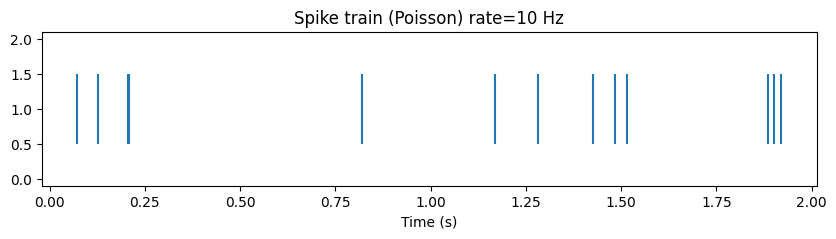

Estimated rate (Hz): 6.5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

T = 2.0          # seconds
dt = 0.001       # 1 ms
t = np.arange(0, T, dt)

def poisson_spikes(rate_hz, t, dt):
    p = rate_hz * dt
    return (np.random.rand(len(t)) < p).astype(int)

rate = 10  # Hz
spikes = poisson_spikes(rate, t, dt)

plt.figure(figsize=(10,2))
plt.eventplot(t[spikes==1])
plt.title(f"Spike train (Poisson) rate={rate} Hz")
plt.xlabel("Time (s)")
plt.show()

print("Estimated rate (Hz):", spikes.sum()/T)

In [3]:
# TODO 1:
# Change rate = 5, 20, 50 and observe the raster + estimated rate.
#Add a rate estimator using a sliding window (students implement a simple moving average).

### Part B — Refractory period (biophysical constraint)
Goal : Show that biology imposes limits on maximum firing rate.

In [4]:
def poisson_spikes_with_refractory(rate_hz, t, dt, refrac_s=0.01):
    p = rate_hz * dt
    spikes = np.zeros(len(t), dtype=int)
    last_spike_t = -np.inf
    for i, ti in enumerate(t):
        if (ti - last_spike_t) >= refrac_s:
            if np.random.rand() < p:
                spikes[i] = 1
                last_spike_t = ti
    return spikes

rate = 80
sp_no_ref = poisson_spikes(rate, t, dt)
sp_ref = poisson_spikes_with_refractory(rate, t, dt, refrac_s=0.01)

print("No ref rate:", sp_no_ref.sum()/T)
print("With ref rate:", sp_ref.sum()/T)

No ref rate: 91.5
With ref rate: 45.5


In [ ]:
# TODO 2:
# Vary refrac_s (2ms, 5ms, 10ms) and plot achieved firing rate vs refractory.
#Compute ISI (inter-spike interval) distribution and show the “gap” caused by refractory.
#(You must write the ISI code.)
#What happen when refactor increase?

### Part C — Rate coding experiment (stimulus intensity → firing rate)

Goal: Show “intensity” is encoded by spike rate, not spike amplitude.


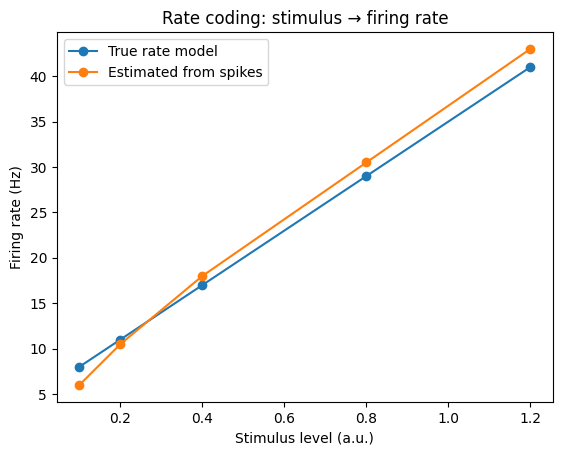

In [6]:
stim_levels = np.array([0.1, 0.2, 0.4, 0.8, 1.2])  # arbitrary stimulus
base = 5
gain = 30

rates = base + gain*stim_levels  # simple encoding model

estimated = []
for r in rates:
    sp = poisson_spikes(r, t, dt)
    estimated.append(sp.sum()/T)

plt.figure()
plt.plot(stim_levels, rates, marker='o', label="True rate model")
plt.plot(stim_levels, estimated, marker='o', label="Estimated from spikes")
plt.xlabel("Stimulus level (a.u.)")
plt.ylabel("Firing rate (Hz)")
plt.title("Rate coding: stimulus → firing rate")
plt.legend()
plt.show()

In [ ]:
# TODO 3: 
#Modify the encoding model: make it nonlinear (e.g., sigmoid or saturation).
#Add noise to stimulus and check stability of rate estimation.
#Explain what happen to the Raster plot and rate estimation. (1-2 sentenses)

### Part D — Timing code (precision/jitter matters)
Goal: Show that information can be carried by precise spike timing, not just counts.

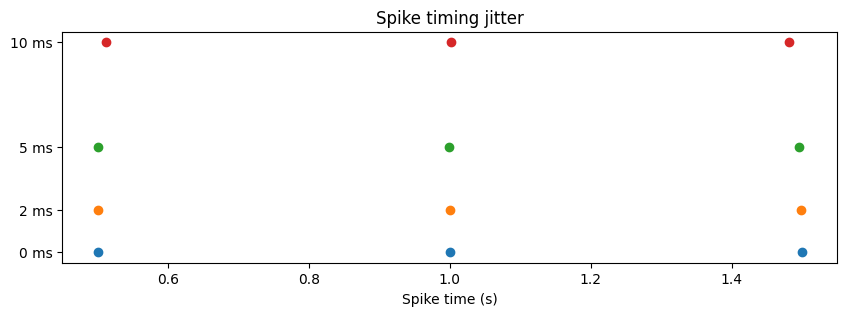

In [7]:
def jitter_spike_times(spike_times, jitter_std, rng=np.random):
    return spike_times + rng.normal(0, jitter_std, size=len(spike_times))

true_times = np.array([0.5, 1.0, 1.5])  # “coded” event times
jitters = [0.0, 0.002, 0.005, 0.01]      # 0–10 ms jitter

plt.figure(figsize=(10,3))
for j in jitters:
    obs = jitter_spike_times(true_times, j)
    plt.plot(obs, np.ones_like(obs)*j, 'o')
plt.yticks(jitters, [f"{int(j*1000)} ms" for j in jitters])
plt.xlabel("Spike time (s)")
plt.title("Spike timing jitter")
plt.show()

In [ ]:
# TODO 4:
#Implement a coincidence detector: count how often spikes fall within a window of a target time.
#Plot detection rate vs jitter.

### Part E — Population coding + simple decoding
Goal: Show that populations reduce noise and enable decoding.

#### Baseline (run): We simulate two stimuli A and B that produce different population rates.

In [8]:
def simulate_population(stim, N=30, T=1.0, dt=0.001):
    t = np.arange(0, T, dt)
    # different rate patterns across neurons
    if stim == "A":
        rates = np.linspace(5, 25, N)
    else:
        rates = np.linspace(25, 5, N)
    spikes = np.array([poisson_spikes(r, t, dt) for r in rates])
    features = spikes.sum(axis=1) / T  # firing rate per neuron (Hz)
    return features

# dataset
X = []
y = []
for _ in range(200):
    X.append(simulate_population("A"))
    y.append(0)
    X.append(simulate_population("B"))
    y.append(1)

X = np.array(X)
y = np.array(y)

# simple linear decoder (no sklearn)
w = X[y==1].mean(axis=0) - X[y==0].mean(axis=0)
b = -0.5 * (X[y==1].mean(axis=0) + X[y==0].mean(axis=0)) @ w

pred = ((X @ w + b) > 0).astype(int)
acc = (pred == y).mean()
print("Decoding accuracy:", acc)

Decoding accuracy: 1.0


In [ ]:
# TODO 5:

# Vary population size N: test N = 5, 10, 20, 50 and plot accuracy vs N.

# Add shared noise (correlation) and observe decoding accuracy drop.



#### Writing questions.

1. Rate coding vs timing coding (2–3 sentences)

2. What refractory changes

3. How population size affects decoding